## Fisher forecast analysis to examine constraints placed on Neff by Planck 2018

This notebook's purpose is to perform a Fisher forecast analysis on Planck 2018, with specific focus on the parameter Neff. 

I used this notebook by Zack Li to learn how to import parameters from CLASS https://github.com/xzackli/fishchips-public/blob/master/notebooks/Introduction%20to%20Fisher%20Forecasting.ipynb

In [345]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class  # CLASS python wrapper (must be installed with pip install classy while in a virtual environment)


In [346]:
def utility_function_call_CLASS(input_dict, l_max=2500):
    cosmo = Class() #create a CLASS object
    cosmo.set(input_dict) #pass the input parameters to CLASS
    cosmo.compute() #Run the CLASS code to compute the cosmological observables (Boltzmann solver )
    temp_cl = cosmo.lensed_cl(l_max) #Extract the lensed C_ell up to l=2000 (as a dictionary)
    cosmo.struct_cleanup() #Free internal CLASS structures to save memory
    cosmo.empty() #Reset the CLASS object to free memory
    return temp_cl


# Define the CLASS input dictionary, use defaults
#### DECIDE FIDUCIAL COSMOLOGY
params = {
    'output': 'tCl lCl',
    'l_max_scalars': 2500,
    'lensing': 'yes',
    'omega_cdm': 0.1206, #Omega_cdm h^2
    'omega_b': 0.02212, #Omega_b h^2
    'h': 0.6688,
    'Neff': 3.046,
    'T_cmb': 2.7255, #CMB temperature in Kelvin
    'ln10^{10}A_s': 3.040, 
    'n_s': 0.9626, ## add neutrino mass also, also theta_s??
    'tau_reio': 0.0522,
}

fiducial=utility_function_call_CLASS(params, l_max=2500) 

def get_deriv(params, x, x_step, channel):  #params is the predefined list of all the parameters, x is what we are taking the derivative with respect to (include ''), x_step is the step size for the numerical derivative, and channel is 'tt', 'tp', or 'pp'
    left_params=params.copy()
    right_params=params.copy()
    left_params[x]=params[x]-x_step
    right_params[x]=params[x]+x_step
    cl_tt_left=utility_function_call_CLASS(left_params)[channel]
    cl_tt_right=utility_function_call_CLASS(right_params)[channel]
    dCltt_dx2=(cl_tt_right-cl_tt_left)/(2*x_step)
    return dCltt_dx2





## Show the Effect of Changing Neff on the CMB Power Spectrum

[0.00000000e+00 0.00000000e+00 1.43828019e-10 ... 4.88516944e-17
 4.88080971e-17 4.87643760e-17]


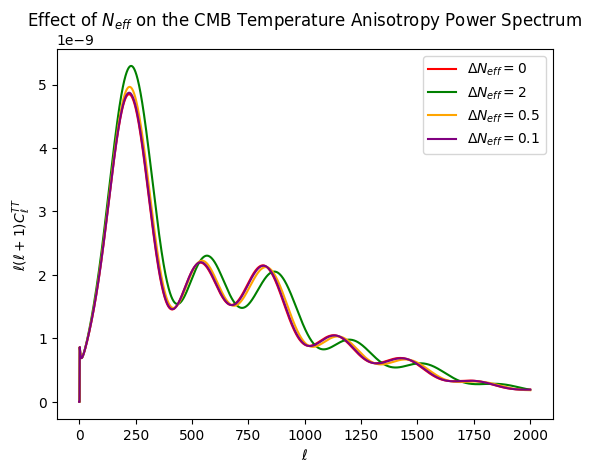

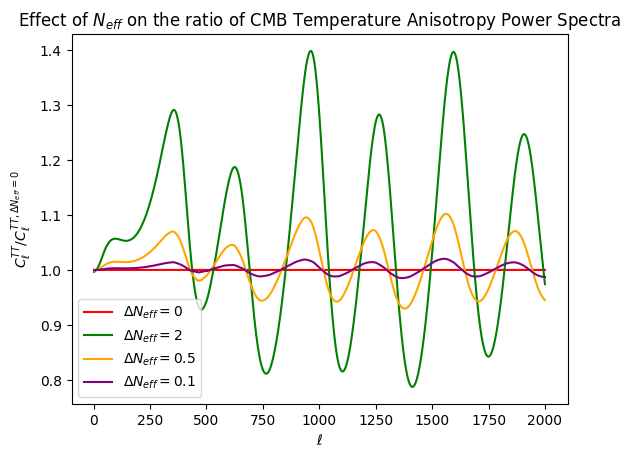

In [347]:
params1 = {
    'output': 'tCl lCl',
    'l_max_scalars': 2000,
    'lensing': 'yes',
    'omega_cdm': 0.120,
    'omega_b': 0.0224, 
    'h': 0.674,
    'Neff': 3.046, #Delta Neff=0
    'T_cmb': 2.7260 
}
fiducial1=utility_function_call_CLASS(params1,l_max=2000)

params2 = {
    'output': 'tCl lCl',
    'l_max_scalars': 2000,
    'lensing': 'yes',
    'omega_cdm': 0.120,
    'omega_b': 0.0224, 
    'h': 0.674,
    'Neff': 5.046, #Delta Neff=2
    'T_cmb': 2.7260 
}

fiducial2=utility_function_call_CLASS(params2, l_max=2000) 


params3 = {
    'output': 'tCl lCl',
    'l_max_scalars': 2000,
    'lensing': 'yes',
    'omega_cdm': 0.120,
    'omega_b': 0.0224, 
    'h': 0.674,
    'Neff': 3.546, #Delta Neff=0.5
    'T_cmb': 2.7260 
}
fiducial3=utility_function_call_CLASS(params3, l_max=2000)


params4 = {
    'output': 'tCl lCl',
    'l_max_scalars': 2000,
    'lensing': 'yes',
    'omega_cdm': 0.120,
    'omega_b': 0.0224, 
    'h': 0.674,
    'Neff': 3.146, #Delta Neff=0.1
    'T_cmb': 2.7260 
}
fiducial4=utility_function_call_CLASS(params4, l_max=2000)


print(fiducial1['tt'])

plt.plot(fiducial1['ell'], fiducial1['ell']*(fiducial1['ell']+1)*fiducial1['tt'], color='red', label=r'$\Delta N_{eff}=0$')
plt.plot(fiducial2['ell'], fiducial2['ell']*(fiducial2['ell']+1)*fiducial2['tt'], color='green', label=r'$\Delta N_{eff}=2$')
plt.plot(fiducial3['ell'], fiducial3['ell']*(fiducial3['ell']+1)*fiducial3['tt'], color='orange', label=r'$\Delta N_{eff}=0.5$')
plt.plot(fiducial4['ell'], fiducial4['ell']*(fiducial4['ell']+1)*fiducial4['tt'], color='purple', label=r'$\Delta N_{eff}=0.1$')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (\ell+1) C_{\ell}^{TT}$')
plt.title(r'Effect of $N_{eff}$ on the CMB Temperature Anisotropy Power Spectrum')
plt.legend()
plt.savefig('Neff_effect_on_CMB_Cl.png')
plt.show()

fiducial_div=fiducial1['tt'][2:] #remove the zeros from the first two entries of the Cl arrays to avoid division by zero
fiducial2_div=fiducial2['tt'][2:] #ensure the size of the arrays matches
fiducial3_div=fiducial3['tt'][2:]
fiducial4_div=fiducial4['tt'][2:]
fiducial_ell=fiducial1['ell'][2:] #also remove the first two entries of the ell array to match the size of the Cl arrays


plt.plot(fiducial_ell, fiducial_div/fiducial_div, color='red', label=r'$\Delta N_{eff}=0$')
plt.plot(fiducial_ell, fiducial2_div/fiducial_div, color='green', label=r'$\Delta N_{eff}=2$')
plt.plot(fiducial_ell, fiducial3_div/fiducial_div, color='orange', label=r'$\Delta N_{eff}=0.5$')
plt.plot(fiducial_ell, fiducial4_div/fiducial_div, color='purple', label=r'$\Delta N_{eff}=0.1$')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$C_{\ell}^{TT}/C_{\ell}^{TT, \Delta N_{eff}=0}$')
plt.title(r'Effect of $N_{eff}$ on the ratio of CMB Temperature Anisotropy Power Spectra')
plt.legend()
plt.savefig('Neff_effect_on_CMB.png')
plt.show()

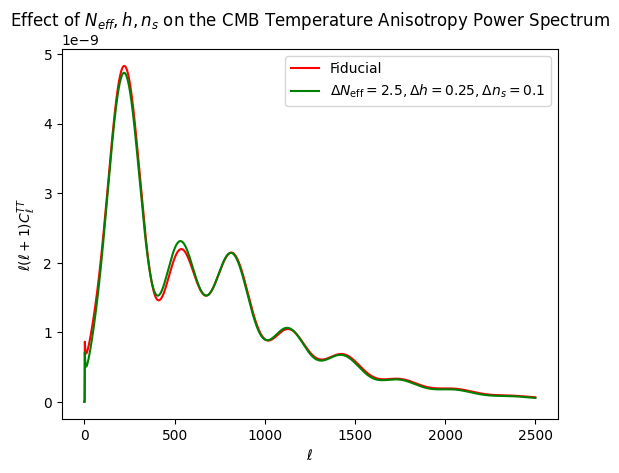

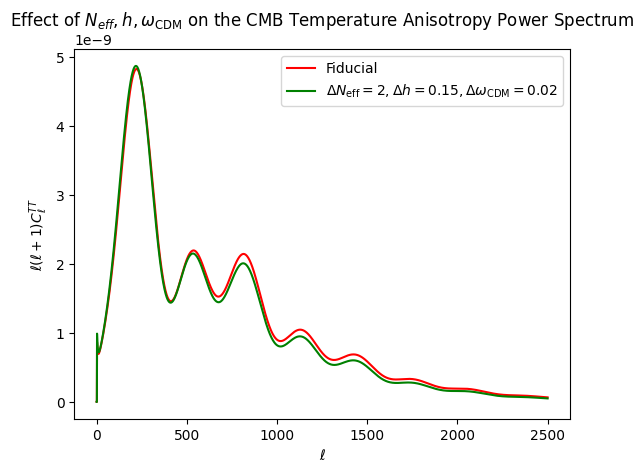

In [348]:
fiducialA1=utility_function_call_CLASS(params, l_max=2500)

paramsA2 = {
    'output': 'tCl lCl',
    'l_max_scalars': 2500,
    'lensing': 'yes',
    'omega_cdm': 0.1206, 
    'omega_b': 0.02212, 
    'h': 0.9188, #increased by 0.25
    'Neff': 5.046, #increased by 2.0
    'T_cmb': 2.7255, 
    'ln10^{10}A_s': 3.040, 
    'n_s': 1.0826,  #increased by 0.1
    'tau_reio': 0.0522,
}
fiducialA2=utility_function_call_CLASS(paramsA2, l_max=2500) 


paramsA3 = {
    'output': 'tCl lCl',
    'l_max_scalars': 2500,
    'lensing': 'yes',
    'omega_cdm': 0.1406, # increased by 0.02
    'omega_b': 0.02212, 
    'h': 0.8188, #increased by 0.15
    'Neff': 5.046, #increased by 2.0
    'T_cmb': 2.7255, 
    'ln10^{10}A_s': 3.040, 
    'n_s': 0.9626,  
    'tau_reio': 0.0522,
}

fiducialA3=utility_function_call_CLASS(paramsA3, l_max=2500) 

plt.plot(fiducialA1['ell'], fiducialA1['ell']*(fiducialA1['ell']+1)*fiducialA1['tt'], color='red', label=r'Fiducial')
plt.plot(fiducialA1['ell'], fiducialA2['ell']*(fiducialA2['ell']+1)*fiducialA2['tt'], color='green', label=r'$\Delta N_\text{eff}=2.5, \Delta h= 0.25,  \Delta n_s=0.1$')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (\ell+1) C_{\ell}^{TT}$')
plt.title(r'Effect of $N_{eff}, h, n_s$ on the CMB Temperature Anisotropy Power Spectrum')
plt.legend()
plt.savefig('Neff_h_ns_effect.png')
plt.show()


plt.plot(fiducialA1['ell'], fiducialA1['ell']*(fiducialA1['ell']+1)*fiducialA1['tt'], color='red', label=r'Fiducial')
plt.plot(fiducialA1['ell'], fiducialA3['ell']*(fiducialA3['ell']+1)*fiducialA3['tt'], color='green', label=r'$\Delta N_\text{eff}=2, \Delta h= 0.15,  \Delta \omega_\text{CDM}=0.02$')
#plt.plot(fiducialA1['ell'], fiducialA3['ell']*(fiducialA3['ell']+1)*fiducialA3['tt'], color='orange', label=r'$\Delta tau=0.1$')
#plt.plot(fiducialA1['ell'], fiducialA4['ell']*(fiducialA4['ell']+1)*fiducialA4['tt'], color='purple', label=r'$\Delta N_{eff}=2$')
#plt.plot(fiducialA1['ell'], fiducialA5['ell']*(fiducialA5['ell']+1)*fiducialA5['tt'], color='blue', label=r'$\Delta A_{s}=0.1, \Delta \tau=0.1$')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (\ell+1) C_{\ell}^{TT}$')
plt.title(r'Effect of $N_{eff}, h, \omega_\text{CDM}$ on the CMB Temperature Anisotropy Power Spectrum')
plt.legend()
plt.savefig('Neff_h_cdm_effect.png')
plt.show()



## Generate Noise

In [349]:
Chan_freq=np.array([100,143,217]) #polarization frequency channels for Planck
theta_FWHM=(np.pi/60./180.)*np.array([9.66,7.22,4.90]) #in radians
Temp_noise=(1/(10**(6)*params['T_cmb']))*(np.pi/180)*np.array([1.29, 0.55, 0.78]) #converted to radians from muK_CMB deg
Pol_noise=(1/(10**(6)*params['T_cmb']))*(np.pi/180)*np.array([1.96, 1.17, 1.75]) 

Nl_TT=np.zeros(2501)
Nl_EE=np.zeros(2501)

for i in range(2501):
    Nl_Temp_arr=Temp_noise**2*np.exp(i*(i+1)*theta_FWHM**2/(8*np.log(2))) #Temperature noise array
    Nl_TT[i]=1/np.sum(1/Nl_Temp_arr) #combinging noise from different frequency channels
    Nl_Pol_arr=Pol_noise**2*np.exp(i*(i+1)*theta_FWHM**2/(8*np.log(2)))
    Nl_EE[i]=1/np.sum(1/Nl_Pol_arr)

## Choose a Step Size

In [350]:
#choose step size based on where the derivative seems stable
steph=(0.00005, 0.0001,0.0005, 0.0007, 0.001,0.005, 0.007, 0.01, 0.05,0.07)
stepN=(0.0005, 0.001, 0.005, 0.007, 0.01, 0.05,0.07,0.1,0.5,0.7)
stepCDM=(0.00005, 0.0001,0.0005, 0.0007, 0.001,0.005, 0.007, 0.01, 0.05,0.07)
stepb=(0.000005, 0.00001,0.00005, 0.00007, 0.0001,0.0005, 0.0007, 0.001, 0.005,0.007)
stepAs=(0.0005, 0.001, 0.005, 0.007, 0.01, 0.05,0.07,0.1,0.5,0.7)
stepns=(0.00005, 0.0001,0.0005, 0.0007, 0.001,0.005, 0.007, 0.01, 0.05,0.07)
steptau=(0.000005, 0.00001,0.00005, 0.00007, 0.0001,0.0005, 0.0007, 0.001, 0.005,0.007)
stepmnu=(0.000005, 0.00001,0.00005, 0.00007, 0.0001,0.0005, 0.0007, 0.001, 0.005,0.007)
steptheta=(0.0005, 0.001, 0.005, 0.007, 0.01, 0.05,0.07,0.1,0.5,0.7)

deriv_h=np.zeros(len(steph))
deriv_Neff=np.zeros(len(stepN))
deriv_CDM=np.zeros(len(stepCDM))
deriv_b=np.zeros(len(stepb))
deriv_As=np.zeros(len(stepAs))
deriv_ns=np.zeros(len(stepns))
deriv_tau=np.zeros(len(steptau))
deriv_mnu=np.zeros(len(stepmnu))
deriv_theta=np.zeros(len(steptheta))



for i in range(len(stepN)):
    deriv_h[i]=get_deriv(params, 'h', steph[i], 'tt')[1000]
    deriv_Neff[i]=get_deriv(params, 'Neff', stepN[i], 'tt')[1000]
    deriv_CDM[i]=get_deriv(params, 'omega_cdm', stepCDM[i], 'tt')[1000]
    deriv_b[i]=get_deriv(params, 'omega_b', stepb[i], 'tt')[1000]
    deriv_As[i]=get_deriv(params, 'ln10^{10}A_s', stepAs[i], 'tt')[1000]
    deriv_ns[i]=get_deriv(params, 'n_s', stepns[i], 'tt')[1000]
    deriv_tau[i]=get_deriv(params, 'tau_reio',steptau[i], 'tt')[1000]





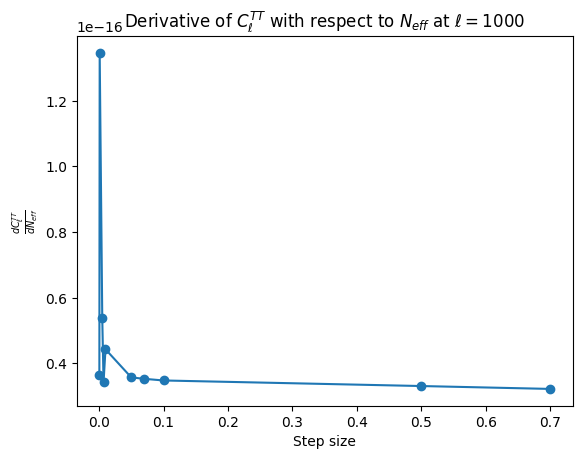

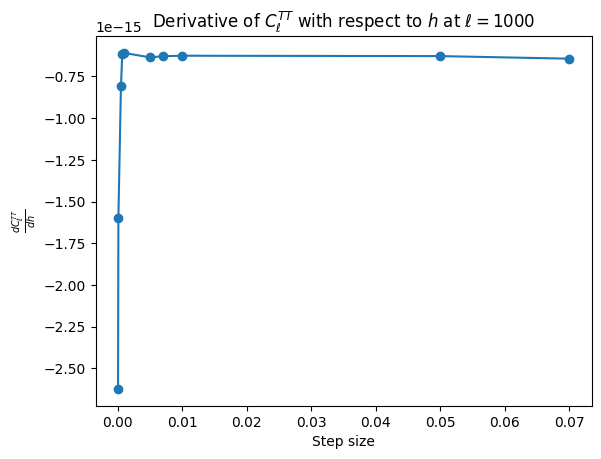

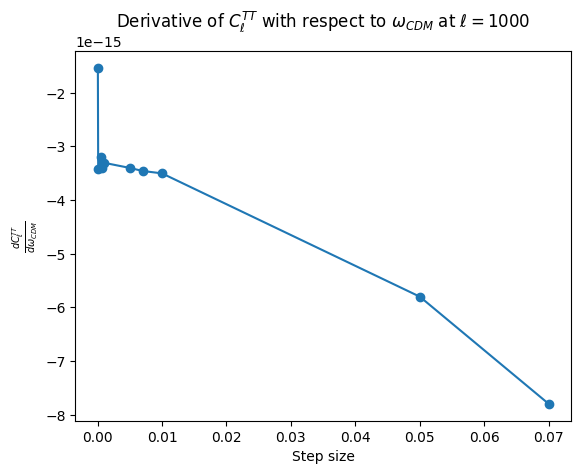

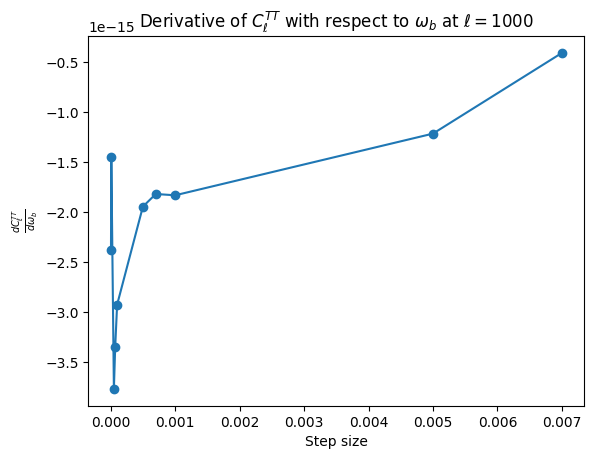

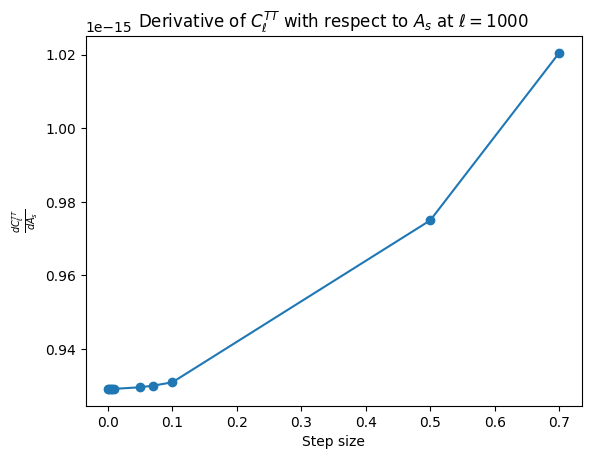

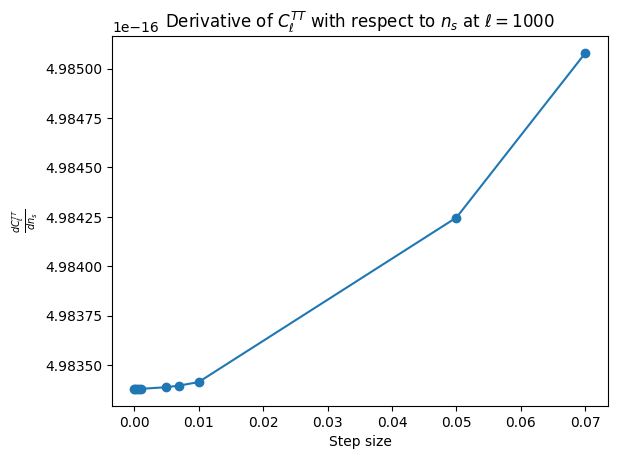

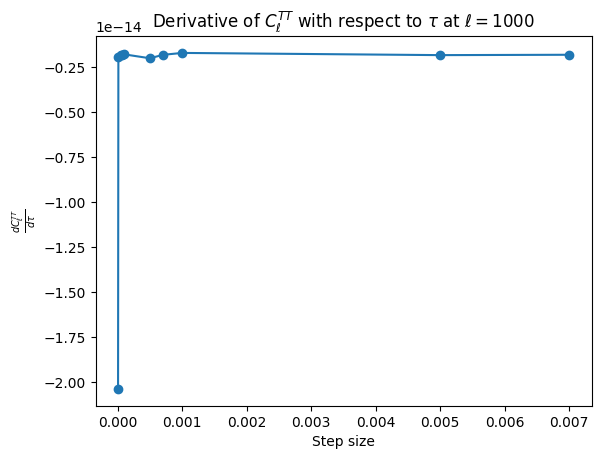

In [351]:
plt.plot(stepN,deriv_Neff,'o-')
plt.title(r'Derivative of $C_\ell^{TT}$ with respect to $N_{eff}$ at $\ell=1000$')
plt.xlabel('Step size')
plt.ylabel(r'$\frac{dC_\ell^{TT}}{dN_{eff}}$')
plt.show()

plt.plot(steph,deriv_h,'o-')
plt.title(r'Derivative of $C_\ell^{TT}$ with respect to $h$ at $\ell=1000$')
plt.xlabel('Step size')
plt.ylabel(r'$\frac{dC_\ell^{TT}}{dh}$')
plt.show()

plt.plot(stepCDM,deriv_CDM,'o-')
plt.title(r'Derivative of $C_\ell^{TT}$ with respect to $\omega_{CDM}$ at $\ell=1000$')
plt.xlabel('Step size')
plt.ylabel(r'$\frac{dC_\ell^{TT}}{d\omega_{CDM}}$')
plt.show()

plt.plot(stepb,deriv_b,'o-')
plt.title(r'Derivative of $C_\ell^{TT}$ with respect to $\omega_{b}$ at $\ell=1000$')
plt.xlabel('Step size')
plt.ylabel(r'$\frac{dC_\ell^{TT}}{d\omega_{b}}$')
plt.show()

plt.plot(stepAs,deriv_As,'o-')
plt.title(r'Derivative of $C_\ell^{TT}$ with respect to $A_{s}$ at $\ell=1000$')
plt.xlabel('Step size')
plt.ylabel(r'$\frac{dC_\ell^{TT}}{dA_{s}}$')
plt.show()

plt.plot(stepns,deriv_ns,'o-')
plt.title(r'Derivative of $C_\ell^{TT}$ with respect to $n_{s}$ at $\ell=1000$')
plt.xlabel('Step size')
plt.ylabel(r'$\frac{dC_\ell^{TT}}{dn_{s}}$')
plt.show()

plt.plot(steptau,deriv_tau,'o-')
plt.title(r'Derivative of $C_\ell^{TT}$ with respect to $\tau$ at $\ell=1000$')
plt.xlabel('Step size')
plt.ylabel(r'$\frac{dC_\ell^{TT}}{d\tau}$')
plt.show()


## Calculate Fisher Matrix

In [352]:
#Create the fisher matrix. 
hstep=0.01 #these step sizes were chosen based on where the derivatives are most stable in the previous plots
Nstep=0.05
CDMstep=0.01
bstep=0.001
Asstep=0.05
nsstep=0.01
taustep=0.001

#derivatives
deriv_N_tt = get_deriv(params, 'Neff', Nstep, 'tt')
deriv_N_tp = get_deriv(params, 'Neff', Nstep, 'tp')
deriv_N_pp = get_deriv(params, 'Neff', Nstep, 'pp')

deriv_h_tt  = get_deriv(params, 'h', hstep, 'tt')
deriv_h_tp  = get_deriv(params, 'h', hstep, 'tp')
deriv_h_pp  = get_deriv(params, 'h', hstep, 'pp')

deriv_CDM_tt = get_deriv(params, 'omega_cdm', CDMstep, 'tt')
deriv_CDM_tp = get_deriv(params, 'omega_cdm', CDMstep, 'tp')
deriv_CDM_pp = get_deriv(params, 'omega_cdm', CDMstep, 'pp')

deriv_b_tt  = get_deriv(params, 'omega_b', bstep, 'tt')
deriv_b_tp  = get_deriv(params, 'omega_b', bstep, 'tp')
deriv_b_pp  = get_deriv(params, 'omega_b', bstep, 'pp')

deriv_As_tt = get_deriv(params, 'ln10^{10}A_s', Asstep, 'tt')
deriv_As_tp = get_deriv(params, 'ln10^{10}A_s', Asstep, 'tp')
deriv_As_pp = get_deriv(params, 'ln10^{10}A_s', Asstep, 'pp')

deriv_ns_tt  = get_deriv(params, 'n_s', nsstep, 'tt')
deriv_ns_tp  = get_deriv(params, 'n_s', nsstep, 'tp')
deriv_ns_pp  = get_deriv(params, 'n_s', nsstep, 'pp')

deriv_tau_tt  = get_deriv(params, 'tau_reio', taustep, 'tt')
deriv_tau_tp  = get_deriv(params, 'tau_reio', taustep, 'tp')
deriv_tau_pp  = get_deriv(params, 'tau_reio', taustep, 'pp')

print(deriv_b_tt)



[ 0.00000000e+00  0.00000000e+00 -4.74768367e-10 ...  4.40662105e-16
  4.38397306e-16  4.36119203e-16]


In [353]:
F=np.zeros((7,7))

fsky = 0.4


F_NN=0
F_hh=0
F_CDMCDM=0
F_bb=0
F_AsAs=0
F_nsns=0
F_tautau=0
F_Nh=0
F_NCDM=0
F_Nb=0
F_NAs=0
F_Nns=0
F_Ntau=0
F_hCDM=0
F_hb=0
F_hAs=0
F_hns=0
F_htau=0
F_CDMb=0
F_CDMAs=0
F_CDMns=0
F_CDMtau=0
F_bAs=0
F_bns=0
F_btau=0
F_Asns=0
F_Astau=0
F_nstau=0



for i in range(30, 2501):
    l = fiducial['ell'][i]
    dCdN = np.array([[deriv_N_tt[l], deriv_N_tp[l]],
                      [deriv_N_tp[l], deriv_N_pp[l]]])
    dCdh  = np.array([[deriv_h_tt[l],  deriv_h_tp[l]],
                      [deriv_h_tp[l],  deriv_h_pp[l]]])
    dCdCDM  = np.array([[deriv_CDM_tt[l],  deriv_CDM_tp[l]],
                      [deriv_CDM_tp[l],  deriv_CDM_pp[l]]])
    dCdb  = np.array([[deriv_b_tt[l],  deriv_b_tp[l]],
                      [deriv_b_tp[l],  deriv_b_pp[l]]])
    dCdAs  = np.array([[deriv_As_tt[l],  deriv_As_tp[l]],
                      [deriv_As_tp[l],  deriv_As_pp[l]]])
    dCdns  = np.array([[deriv_ns_tt[l],  deriv_ns_tp[l]],
                      [deriv_ns_tp[l],  deriv_ns_pp[l]]])
    dCdtau  = np.array([[deriv_tau_tt[l],  deriv_tau_tp[l]],
                      [deriv_tau_tp[l],  deriv_tau_pp[l]]])
    Cll   = np.array([[fiducial['tt'][l]+Nl_TT[l], fiducial['tp'][l]],
                      [fiducial['tp'][l], fiducial['pp'][l]+Nl_EE[l]]])
    Cll_inv = np.linalg.inv(Cll)
    F_NN += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdN @ Cll_inv @ dCdN)
    F_hh += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdh @ Cll_inv @ dCdh)
    F_CDMCDM += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdCDM @ Cll_inv @ dCdCDM)
    F_bb += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdb @ Cll_inv @ dCdb)
    F_AsAs += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdAs @ Cll_inv @ dCdAs)
    F_nsns += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdns @ Cll_inv @ dCdns)
    F_Nh += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdN @ Cll_inv @ dCdh)
    F_NCDM += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdN @ Cll_inv @ dCdCDM)
    F_Nb += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdN @ Cll_inv @ dCdb)
    F_NAs += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdN @ Cll_inv @ dCdAs)
    F_Nns += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdN @ Cll_inv @ dCdns)
    F_hCDM += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdh @ Cll_inv @ dCdCDM)
    F_hb += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdh @ Cll_inv @ dCdb)
    F_hAs += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdh @ Cll_inv @ dCdAs)
    F_hns += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdh @ Cll_inv @ dCdns)
    F_CDMb += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdCDM @ Cll_inv @ dCdb)
    F_CDMAs += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdCDM @ Cll_inv @ dCdAs)
    F_CDMns += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdCDM @ Cll_inv @ dCdns)
    F_bAs += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdb @ Cll_inv @ dCdAs)
    F_bns += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdb @ Cll_inv @ dCdns)
    F_Asns += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdAs @ Cll_inv @ dCdns)
    F_tautau += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdtau @ Cll_inv @ dCdtau)
    F_Ntau += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdN @ Cll_inv @ dCdtau)
    F_htau += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdh @ Cll_inv @ dCdtau)
    F_CDMtau += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdCDM @ Cll_inv @ dCdtau)
    F_btau += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdb @ Cll_inv @ dCdtau)
    F_Astau += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdAs @ Cll_inv @ dCdtau)
    F_nstau += ((2*l+1)/2) * fsky * np.trace(Cll_inv @ dCdns @ Cll_inv @ dCdtau)


F[0][0]=F_NN
F[1][1]=F_hh
F[2][2]=F_CDMCDM
F[3][3]=F_bb
F[4][4]=F_AsAs
F[5][5]=F_nsns
F[6][6]=F_tautau

F[1][0]=F_Nh
F[0][1]=F_Nh

F[2][0]=F_NCDM
F[0][2]=F_NCDM

F[3][0]=F_Nb
F[0][3]=F_Nb

F[4][0]=F_NAs
F[0][4]=F_NAs

F[5][0]=F_Nns
F[0][5]=F_Nns

F[6][0]=F_Ntau
F[0][6]=F_Ntau

F[2][1]=F_hCDM
F[1][2]=F_hCDM

F[3][1]=F_hb
F[1][3]=F_hb

F[4][1]=F_hAs
F[1][4]=F_hAs

F[5][1]=F_hns
F[1][5]=F_hns

F[6][1]=F_htau
F[1][6]=F_htau

F[3][2]=F_CDMb
F[2][3]=F_CDMb

F[4][2]=F_CDMAs
F[2][4]=F_CDMAs

F[5][2]=F_CDMns
F[2][5]=F_CDMns

F[6][2]=F_CDMtau
F[2][6]=F_CDMtau

F[3][4]=F_bAs
F[4][3]=F_bAs

F[3][5]=F_bns
F[5][3]=F_bns

F[3][6]=F_btau
F[6][3]=F_btau

F[4][5]=F_Asns
F[5][4]=F_Asns

F[4][6]=F_Astau
F[6][4]=F_Astau

F[5][6]=F_nstau
F[6][5]=F_nstau

F2=F[:6,:6] #Fisher matrix with tau removed

Cov=np.linalg.inv(F) #covariance matrix
Cov2=np.linalg.inv(F2) #covariance matrix with tau removed



## Plot Results

In [354]:
#Plot results
alpha=[1.52, 2.48, 3.44]

def plot_ellipse(sigma_x, sigma_y, sigma_xy, xc, yc, title, savefig, xaxis, yaxis, n=4):
    phi = np.linspace(0, 2*np.pi, 100)
    a=np.sqrt((sigma_x**2+sigma_y**2)/2+np.sqrt((sigma_x**2-sigma_y**2)**2/4+sigma_xy**2))
    b=np.sqrt((sigma_x**2+sigma_y**2)/2-np.sqrt((sigma_x**2-sigma_y**2)**2/4+sigma_xy**2))
    theta=0.5*np.arctan2((2*sigma_xy),(sigma_x**2-sigma_y**2))
    
    x1 = alpha[0]*a*np.cos(phi)
    y1 = alpha[0]*b*np.sin(phi)
    x2 = alpha[1]*a*np.cos(phi)
    y2 = alpha[1]*b*np.sin(phi)
    
    xr1 = xc + x1*np.cos(theta) - y1*np.sin(theta)
    yr1 = yc + x1*np.sin(theta) + y1*np.cos(theta)
    xr2 = xc + x2*np.cos(theta) - y2*np.sin(theta)
    yr2 = yc + x2*np.sin(theta) + y2*np.cos(theta)
    
    fig, ax = plt.subplots()
    ax.plot(xr1, yr1, color='blue', label=r'$1\sigma$')
    ax.plot(xr2, yr2, ls='dashed', color='green', label=r'$2\sigma$')
    ax.scatter(xc, yc, s=5, color='red', label='Fiducial Point')

    
    ax.set_xlim(xc - n*sigma_x, xc + n*sigma_x)
    ax.set_ylim(yc - n*sigma_y, yc + n*sigma_y)
    
    # Set aspect ratio to match the data ranges, not the units
    ax.set_aspect('auto')
    
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel(xaxis)
    ax.set_ylabel(yaxis)
    plt.savefig(savefig)
    plt.show()


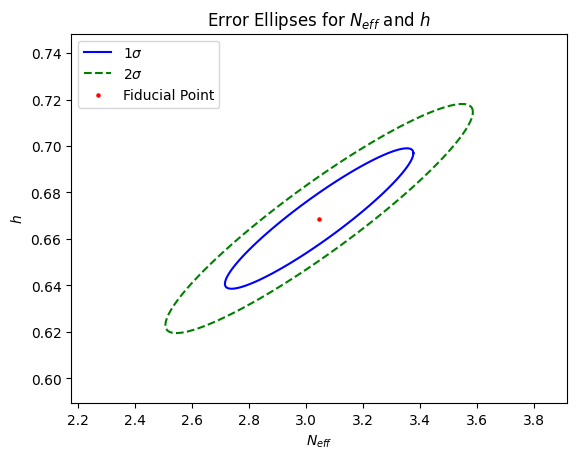

$\rho$ is 0.9298686393272588


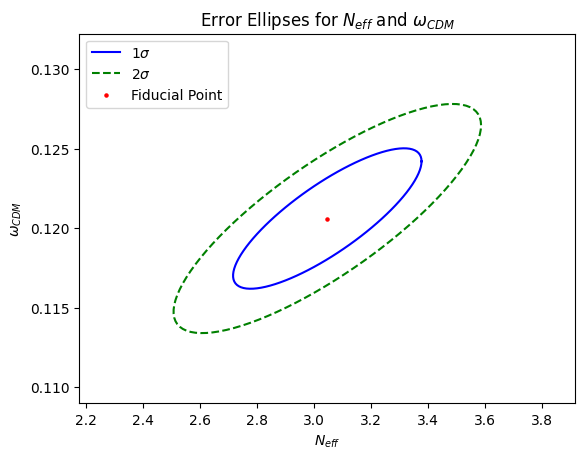

$\rho$ is 0.8142228882252777


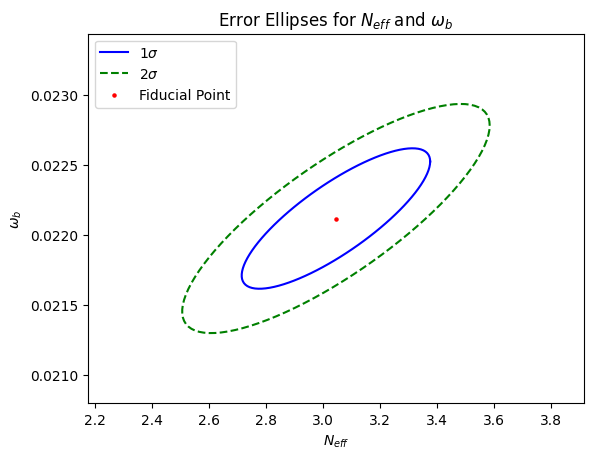

$\rho$ is 0.8116457263877701


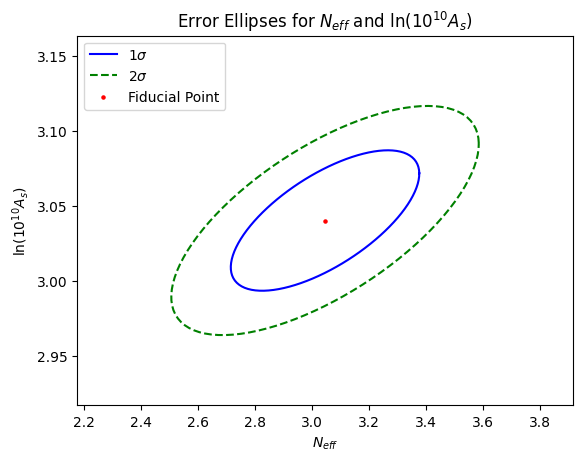

$\rho$ is 0.6671209874863305


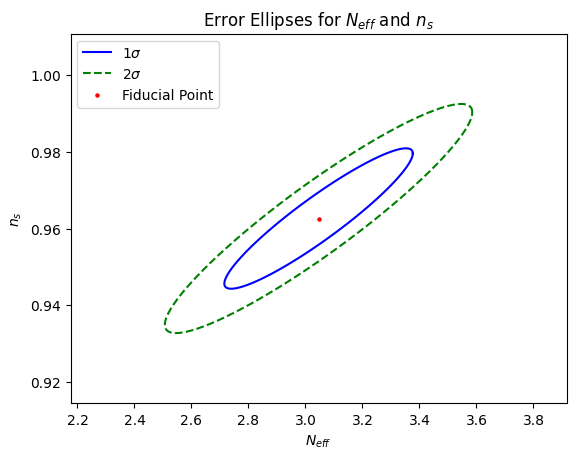

$\rho$ is 0.927462158947695


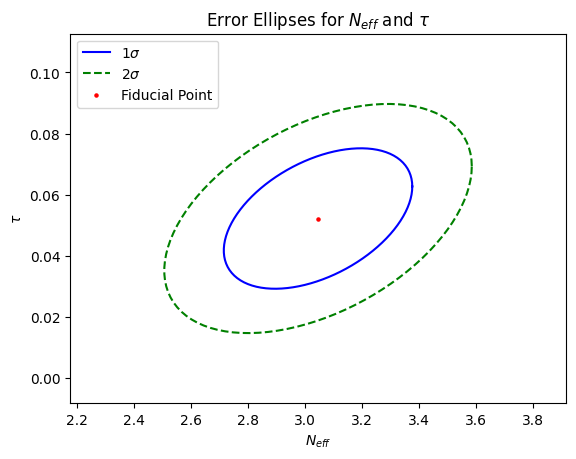

$\rho$ is 0.45536448669392


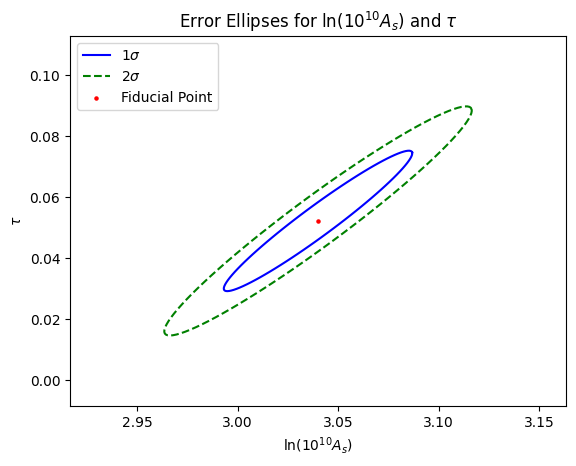

$\rho$ is 0.9635669450999721


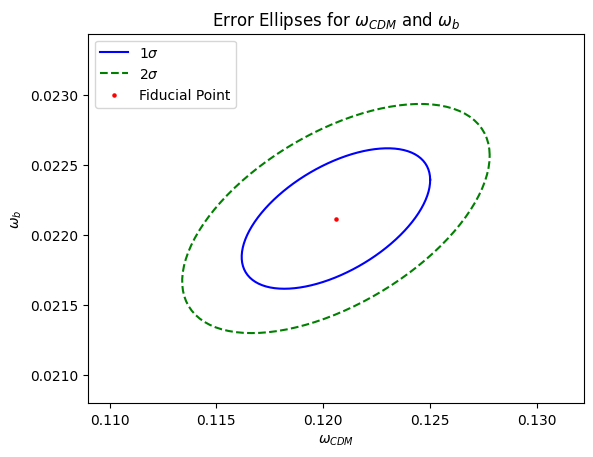

$\rho$ is 0.5480472864259498


In [355]:
plot_ellipse(np.sqrt(Cov[0][0]), np.sqrt(Cov[1][1]), Cov[0][1], params['Neff'], params['h'], r'Error Ellipses for $N_{eff}$ and $h$', 'ErrorNeffh.png', r'$N_{eff}$', r'$h$')
print(r'$\rho$ is',Cov[0][1]/(np.sqrt(Cov[0][0])*np.sqrt(Cov[1][1])))


plot_ellipse(np.sqrt(Cov[0][0]), np.sqrt(Cov[2][2]), Cov[0][2], params['Neff'], params['omega_cdm'], r'Error Ellipses for $N_{eff}$ and $\omega_{CDM}$', 'ErrorNeffCDM.png',r'$N_{eff}$', r'$\omega_{CDM}$')
print(r'$\rho$ is',Cov[0][2]/(np.sqrt(Cov[0][0])*np.sqrt(Cov[2][2])))

plot_ellipse(np.sqrt(Cov[0][0]), np.sqrt(Cov[3][3]), Cov[0][3], params['Neff'], params['omega_b'], r'Error Ellipses for $N_{eff}$ and $\omega_{b}$','ErrorNeffb.png', r'$N_{eff}$', r'$\omega_b$')
print(r'$\rho$ is',Cov[0][3]/(np.sqrt(Cov[0][0])*np.sqrt(Cov[3][3])))

plot_ellipse(np.sqrt(Cov[0][0]), np.sqrt(Cov[4][4]), Cov[0][4], params['Neff'], params['ln10^{10}A_s'], r'Error Ellipses for $N_{eff}$ and $\ln(10^{10} A_s) $','ErrorNeffAs.png', r'$N_{eff}$', r'$\ln(10^{10} A_s)$')
print(r'$\rho$ is',Cov[0][4]/(np.sqrt(Cov[0][0])*np.sqrt(Cov[4][4])))



#plot_ellipse(np.sqrt(Cov[2][2]), np.sqrt(Cov[1][1]), Cov[1][2], params['omega_cdm'], params['h'], r'Error Ellipses for $\omega_{CDM}$ and $h$', r'$\omega_{CDM}$', r'$h$')
#print(r'$\rho is', Cov[1][2]/(np.sqrt(Cov[2][2])*np.sqrt(Cov[1][1]))) ##rho greater than 1??

plot_ellipse(np.sqrt(Cov[0][0]), np.sqrt(Cov[5][5]), Cov[0][5], params['Neff'], params['n_s'], r'Error Ellipses for $N_{eff}$ and $n_s$', 'ErrorNeffns.png', r'$N_{eff}$', r'$n_s$')
print(r'$\rho$ is',Cov[0][5]/(np.sqrt(Cov[0][0])*np.sqrt(Cov[5][5])))

plot_ellipse(np.sqrt(Cov[0][0]), np.sqrt(Cov[6][6]), Cov[0][6], params['Neff'], params['tau_reio'], r'Error Ellipses for $N_{eff}$ and $\tau$','ErrorNefftau.png', r'$N_{eff}$', r'$\tau$')
print(r'$\rho$ is',Cov[0][6]/(np.sqrt(Cov[0][0])*np.sqrt(Cov[6][6])))

plot_ellipse(np.sqrt(Cov[4][4]), np.sqrt(Cov[6][6]), Cov[6][4], params['ln10^{10}A_s'], params['tau_reio'], r'Error Ellipses for $\ln(10^{10} A_s) $ and $\tau$','ErrorAstau.png', r'$\ln(10^{10} A_s)$', r'$\tau$',)
print(r'$\rho$ is',Cov[6][4]/(np.sqrt(Cov[6][6])*np.sqrt(Cov[4][4])))

plot_ellipse(np.sqrt(Cov[2][2]), np.sqrt(Cov[3][3]), Cov[2][3], params['omega_cdm'], params['omega_b'], r'Error Ellipses for $\omega_{CDM}$ and $\omega_{b}$','ErrorCMb.png', r'$\omega_{CDM}$', r'$\omega_b$')
print(r'$\rho$ is',Cov[3][2]/(np.sqrt(Cov[2][2])*np.sqrt(Cov[3][3])))

In [356]:
print(np.sqrt(Cov[0][0])) #error on Neff if other parameters are marginalized over
print(np.sqrt(Cov[0][0])/params['Neff']*100,'%') #percentage error on Neff

#If the other parameters are fixed, then the error on Neff is (F_11)**(-1/2)
print((F[0][0])**(-1/2)) #error on Neff if other parameters are fixed
print((F[0][0])**(-1/2)/params['Neff']*100, '%') #percentage error on Neff

0.21754100535773385
7.141858350549373 %
0.012548915286767609
0.4119801473003155 %


In [ ]:
#Errors for the other parameters
print(np.sqrt(Cov[1][1]),'h')
print(np.sqrt(Cov[2][2]),'omega_cdm')
print(np.sqrt(Cov[3][3]),'omega_b')
print(np.sqrt(Cov[4][4]),'ln10^{10}A_s')
print(np.sqrt(Cov[5][5]),'n_s')
print(np.sqrt(Cov[6][6]),'tau_reio')
print(' ')
print(np.sqrt(Cov[1][1])/params['h']*100,'%' ,'h')
print(np.sqrt(Cov[2][2])/params['omega_cdm']*100,'%', 'omega_CDM')
print(np.sqrt(Cov[3][3])/params['omega_b']*100,'%', 'omega_b')
print(np.sqrt(Cov[4][4])/params['ln10^{10}A_s']*100,'%', 'ln10^10 A_s')
print(np.sqrt(Cov[5][5])/params['n_s']*100,'%', 'n_s')
print(np.sqrt(Cov[6][6])/params['tau_reio']*100,'%', 'tau')

0.01988020531445748 h
0.0029040432721767575 omega_cdm
0.00032987676176608955 omega_b
0.030803509675008695 ln10^{10}A_s
0.012029013795865162 n_s
0.0151152885733908 tau_reio
 
2.9725187372095516 % h
2.407996079748555 % omega_CDM
1.491305432938922 % omega_b
1.0132733445726543 % ln10^10 A_s
1.2496378346005779 % n_s
28.956491519905743 % tau


In [ ]:
##Errors after tau has been fixed
print(np.sqrt(Cov2[0][0])/params['Neff']*100,'%')
print(np.sqrt(Cov2[1][1])/params['h']*100,'%')
print(np.sqrt(Cov2[2][2])/params['omega_cdm']*100,'%')
print(np.sqrt(Cov2[3][3])/params['omega_b']*100,'%')
print(np.sqrt(Cov2[4][4])/params['ln10^{10}A_s']*100,'%')
print(np.sqrt(Cov2[5][5])/params['n_s']*100,'%')
print('')
print(np.sqrt(Cov2[0][0]))
print(np.sqrt(Cov2[1][1]))
print(np.sqrt(Cov2[2][2]))
print(np.sqrt(Cov2[3][3]))
print(np.sqrt(Cov2[4][4]))
print(np.sqrt(Cov2[5][5]))

6.358432965803103 %
2.0542491438716928 %
2.3917603070388243 %
1.2305761412527934 %
0.27101745862622634 %
0.923773355940375 %

0.1936778681383625
0.013738818274213879
0.002884462930288822
0.0002722034424451179
0.00823893074223728
0.00889224232428205


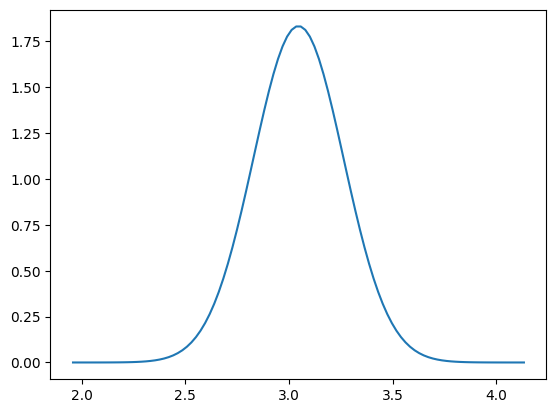

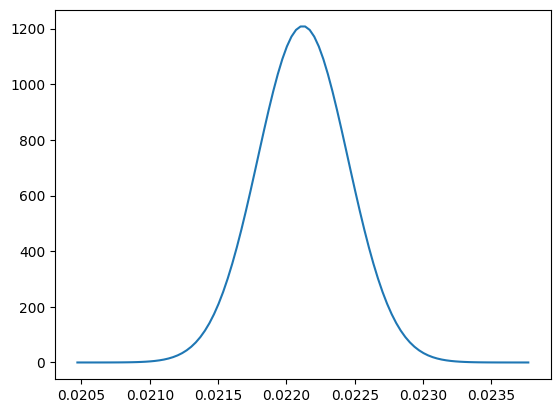

In [ ]:
#Plotting Gaussian curves using the errors given from F
def gaussian(mean,sigma):
    array=np.linspace(mean-5*sigma,mean+5*sigma,100)
    prob=1/(np.sqrt(2*np.pi*sigma**2))*np.exp(-(array-mean)**2/(2*sigma**2))
    return array, prob

Neffprob=gaussian(params['Neff'],np.sqrt(Cov[0][0]))
plt.plot(Neffprob[0],Neffprob[1])
plt.show()

omegabprob=gaussian(params['omega_b'],np.sqrt(Cov[3][3]))
plt.plot(omegabprob[0],omegabprob[1])
plt.show()

In [373]:

#Triangle plot with a wide range of error ellipses and gaussians 

from matplotlib.patches import Ellipse, Patch

# ── Parameter labels & fiducial values ──────────────────────────────────────
PARAM_KEYS = [
    'Neff',
    'h',
    'omega_cdm',
    'omega_b',
    'ln10^{10}A_s',
    'n_s',
    'tau_reio',
]
 
PARAM_LABELS = [
    r'$N_\mathrm{eff}$',
    r'$h$',
    r'$\omega_\mathrm{cdm}$',
    r'$\omega_b$',
    r'$\ln(10^{10}A_s)$',
    r'$n_s$',
    r'$\tau_\mathrm{reio}$',
]
 
# Confidence-level scale factors for a 2D Gaussian ellipse (Table 1 of paper)
# 1σ → Δχ²=2.30 → α=1.52,  2σ → Δχ²=6.17 → α=2.48
SIGMA_LEVELS = [np.sqrt(2.30), np.sqrt(6.17)]
FILL_COLORS  = ['#4575b4', '#74c476']   # blue (inner 1σ), green (outer 2σ)
EDGE_COLORS  = ['#2166ac', '#238b45']
 
 
# ── Helper: ellipse parameters from 2x2 covariance ──────────────────────────
def _ellipse_params(cov2x2):
    """
    Return (width_1, height_1, angle_deg) for a 2-D covariance sub-matrix,
    where width_1 and height_1 are the 1-sigma semi-axes (before multiplying
    by the confidence-level scale factor alpha), and angle_deg is the
    counter-clockwise rotation of the major axis from the x-axis in degrees.
 
    Uses eq. (2-4) from the reference paper:
        a² = (σx²+σy²)/2 + sqrt(((σx²-σy²)/2)² + σxy²)   [major semi-axis]
        b² = (σx²+σy²)/2 - sqrt(((σx²-σy²)/2)² + σxy²)   [minor semi-axis]
        tan(2θ) = 2σxy / (σx² - σy²)
    """
    sxx = cov2x2[0, 0]
    sxy = cov2x2[0, 1]
    syy = cov2x2[1, 1]
 
    term = np.sqrt(((sxx - syy) / 2) ** 2 + sxy ** 2)
 
    l1 = (sxx + syy) / 2 + term   # larger eigenvalue  → major semi-axis
    l2 = (sxx + syy) / 2 - term   # smaller eigenvalue → minor semi-axis
    l2 = max(l2, 0.0)              # numerical safety
 
    width_1  = np.sqrt(l1)         # major semi-axis at 1σ
    height_1 = np.sqrt(l2)         # minor semi-axis at 1σ
 
    # Angle of major axis from x-axis (eq. 4), in degrees
    angle_deg = 0.5 * np.degrees(np.arctan2(2 * sxy, sxx - syy))
 
    return width_1, height_1, angle_deg
 
 
# ── Helper: 1-D Gaussian ─────────────────────────────────────────────────────
def _gaussian(mean, sigma, n=300):
    x = np.linspace(mean - 4 * sigma, mean + 4 * sigma, n)
    y = np.exp(-0.5 * ((x - mean) / sigma) ** 2)
    return x, y
 
 
# ── Main plot function ────────────────────────────────────────────────────────
def plot_fisher_triangle(
    Cov,
    params,
    param_keys=None,
    param_labels=None,
    sigma_levels=None,
    fill_colors=None,
    edge_colors=None,
    figsize=None,
    n_sigma_range=3,
    savefig=None,
):
    """
    Draw a triangle / corner plot of Fisher-matrix error ellipses.
 
    Parameters
    ----------
    Cov           : (N, N) array – covariance matrix (= F^{-1})
    params        : dict         – fiducial parameter values
    param_keys    : list of str  – keys into params (length N)
    param_labels  : list of str  – axis labels (LaTeX ok)
    sigma_levels  : list of float – confidence-level radii (default 1σ, 2σ)
    fill_colors   : list of str  – fill colour for each level (inner→outer)
    edge_colors   : list of str  – edge colour for each level
    figsize       : tuple        – figure size in inches
    n_sigma_range : float        – axis half-width in units of marginal σ
    savefig       : str or None  – filename to save (e.g. 'triangle.pdf')
    """
    if param_keys   is None: param_keys   = PARAM_KEYS
    if param_labels is None: param_labels = PARAM_LABELS
    if sigma_levels is None: sigma_levels = SIGMA_LEVELS
    if fill_colors  is None: fill_colors  = FILL_COLORS
    if edge_colors  is None: edge_colors  = EDGE_COLORS
 
    N = len(param_keys)
    fiducials = [params[k] for k in param_keys]
    sigmas    = [np.sqrt(Cov[i, i]) for i in range(N)]
 
    if figsize is None:
        figsize = (2.5 * N, 2.5 * N)
 
    fig, axes = plt.subplots(N, N, figsize=figsize)
    fig.subplots_adjust(hspace=0.05, wspace=0.05)
 
    for row in range(N):
        for col in range(N):
            ax = axes[row, col]
 
            # ── upper triangle: hide ──────────────────────────────────────
            if col > row:
                ax.set_visible(False)
                continue
 
            # ── diagonal: 1-D Gaussian ────────────────────────────────────
            if col == row:
                x, y = _gaussian(fiducials[row], sigmas[row])
                ax.fill_between(x, y, alpha=0.7, color=fill_colors[1])
                ax.plot(x, y, color=edge_colors[1], lw=1.0)
                ax.set_xlim(
                    fiducials[row] - n_sigma_range * sigmas[row],
                    fiducials[row] + n_sigma_range * sigmas[row],
                )
                ax.set_ylim(0, None)
                ax.set_yticks([])
                ax.yaxis.set_visible(False)
 
            # ── lower triangle: error ellipses ────────────────────────────
            else:
                xc = fiducials[col]   # x-axis = column parameter
                yc = fiducials[row]   # y-axis = row parameter
 
                cov2 = np.array([
                    [Cov[col, col], Cov[col, row]],
                    [Cov[row, col], Cov[row, row]],
                ])
 
                width_1, height_1, angle_deg = _ellipse_params(cov2)
 
                # draw outer (2σ) first, then inner (1σ) on top
                for level, fc, ec in zip(
                    reversed(sigma_levels),
                    reversed(fill_colors),
                    reversed(edge_colors),
                ):
                    ell = Ellipse(
                        xy=(xc, yc),
                        width=2 * level * width_1,
                        height=2 * level * height_1,
                        angle=angle_deg,
                        facecolor=fc,
                        edgecolor=ec,
                        alpha=0.7,
                        linewidth=0.8,
                    )
                    ax.add_patch(ell)
 
                ax.set_xlim(
                    xc - n_sigma_range * sigmas[col],
                    xc + n_sigma_range * sigmas[col],
                )
                ax.set_ylim(
                    yc - n_sigma_range * sigmas[row],
                    yc + n_sigma_range * sigmas[row],
                )
                ax.set_aspect('auto')
 
            # ── tick / label formatting ───────────────────────────────────
            ax.tick_params(labelsize=7, direction='in', top=True, right=True)
 
            # x-axis label on bottom row only
            if row == N - 1:
                ax.set_xlabel(param_labels[col], fontsize=9)
                plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
            else:
                ax.set_xticklabels([])
 
            # y-axis label on left column only (skip diagonal)
            if col == 0 and row != 0:
                ax.set_ylabel(param_labels[row], fontsize=9)
            else:
                ax.set_yticklabels([])
 
    # ── legend ───────────────────────────────────────────────────────────────
    legend_elements = [
        Patch(facecolor=fill_colors[0], edgecolor=edge_colors[0],
              alpha=0.7, label=r'$1\sigma$'),
        Patch(facecolor=fill_colors[1], edgecolor=edge_colors[1],
              alpha=0.7, label=r'$2\sigma$'),
    ]
    fig.legend(
        handles=legend_elements,
        loc='upper right',
        bbox_to_anchor=(0.98, 0.98),
        fontsize=10,
        frameon=True,
    )
 
    fig.suptitle('CMB Fisher Matrix — Error Ellipses', fontsize=13, y=1.01)
 
    if savefig:
        fig.savefig(savefig, dpi=150, bbox_inches='tight')
        print(f'Saved to {savefig}')
 
    plt.tight_layout()
    plt.show()
    return fig, axes

Saved to fisher_triangle.png


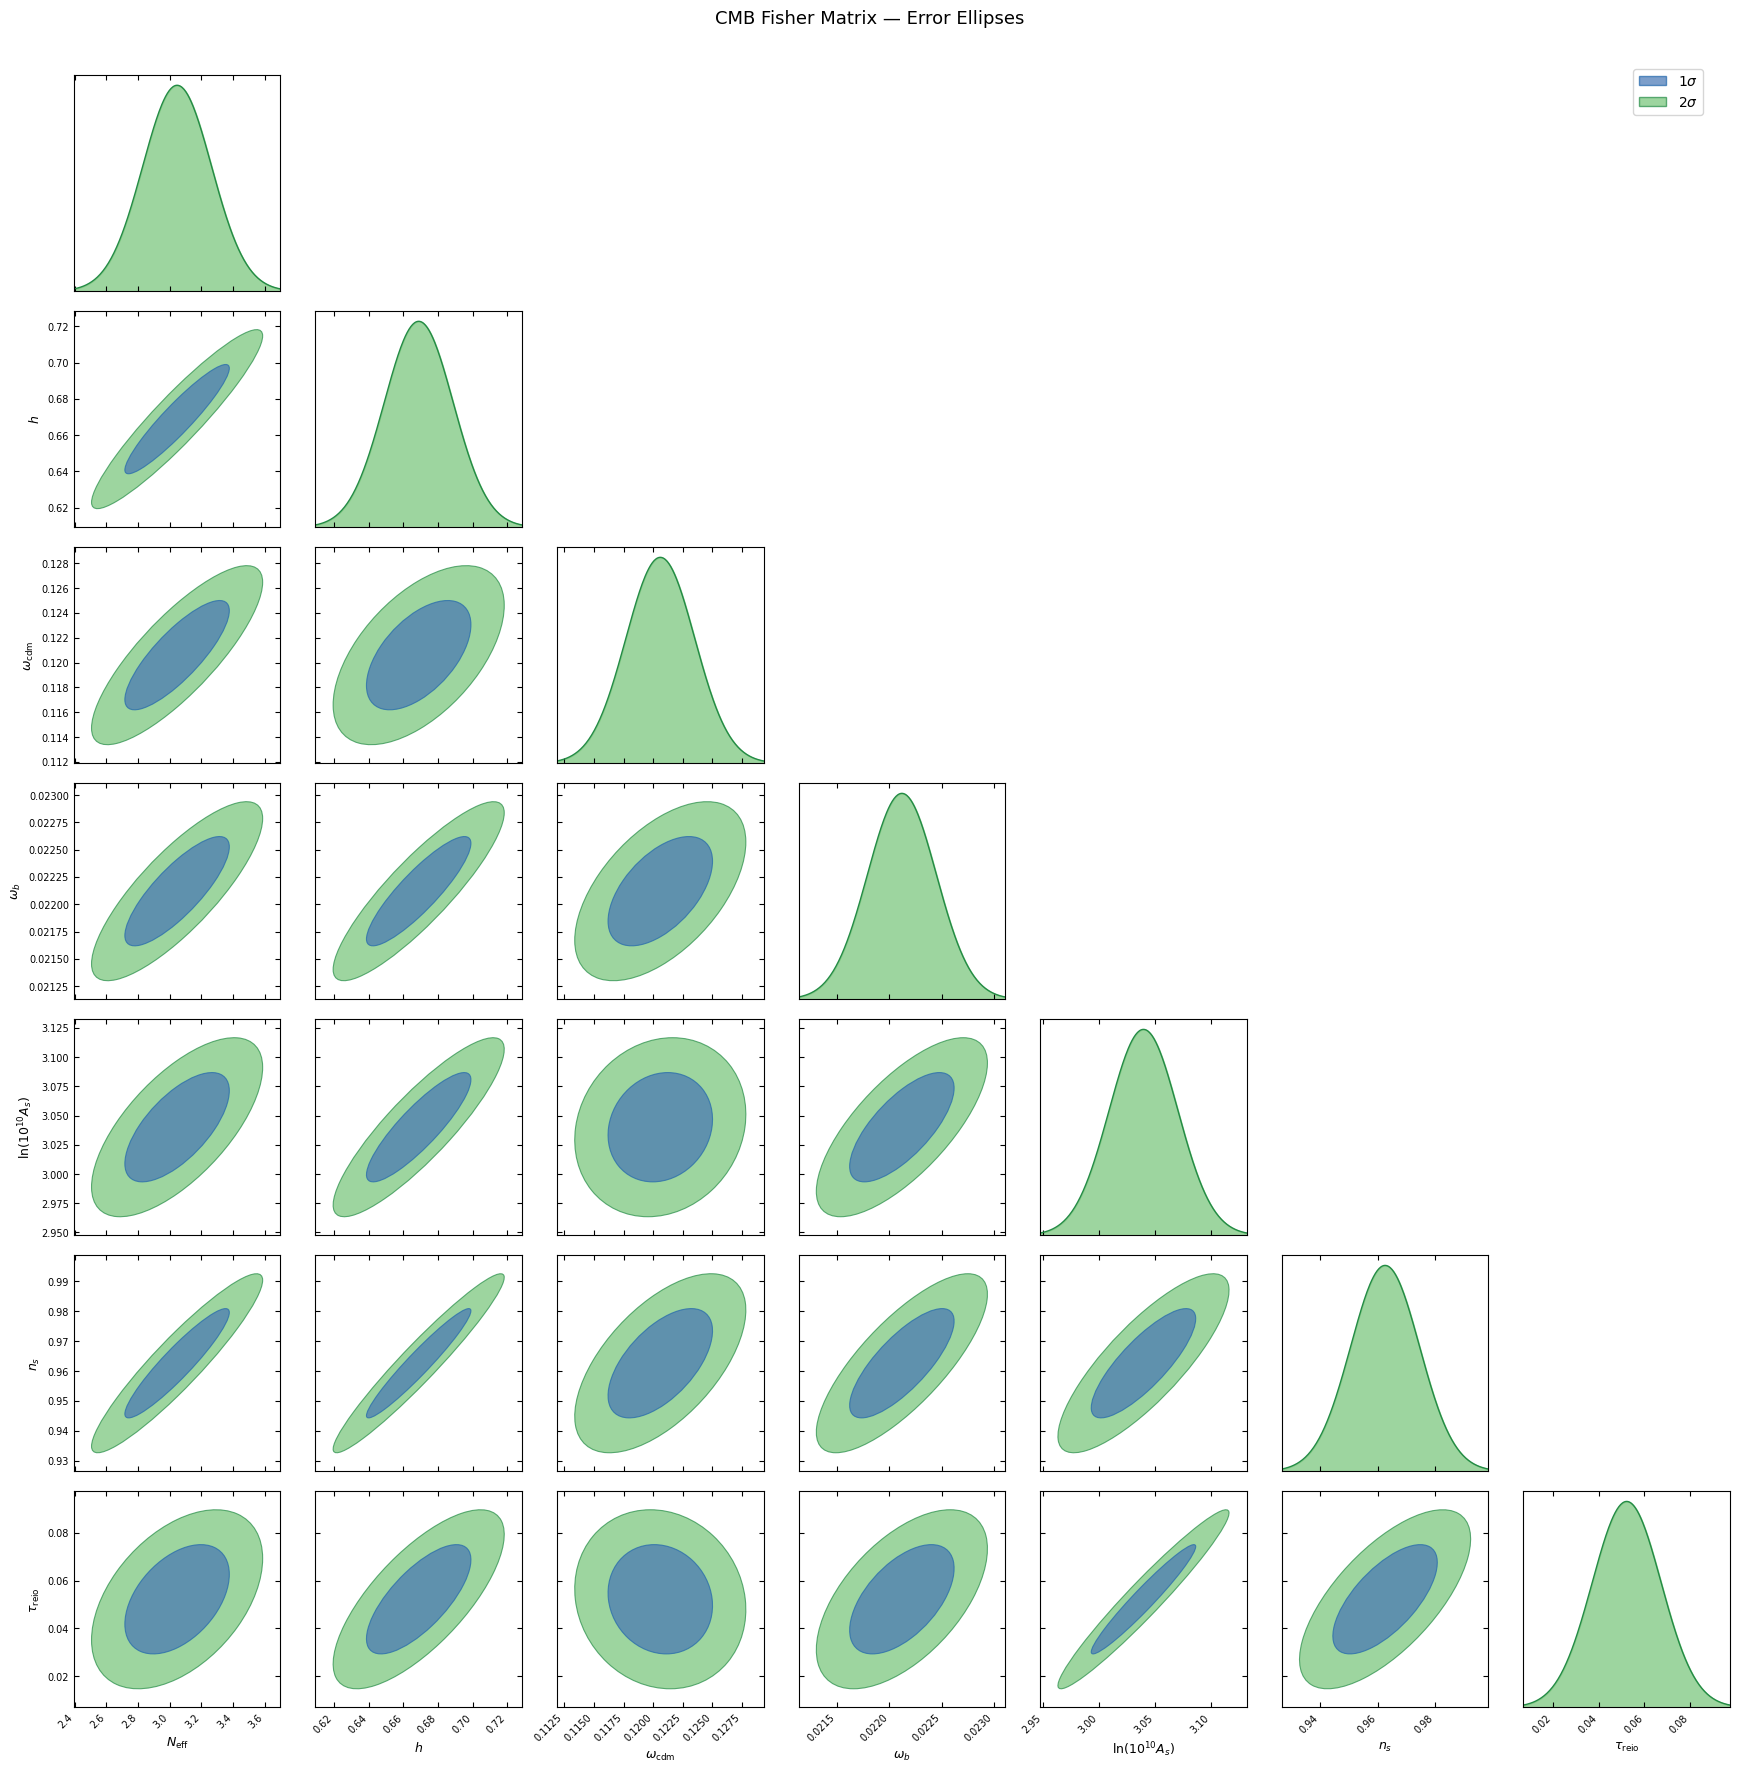

(<Figure size 1750x1750 with 49 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >],
        [<Axes: ylabel='$h$'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: ylabel='$\\omega_\\mathrm{cdm}$'>, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='$\\omega_b$'>, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='$\\ln(10^{10}A_s)$'>, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='$n_s$'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >],
        [<Axes: xlabel='$N_\\mathrm{eff}$', ylabel='$\\tau_\\mathrm{reio}$'>,
         <Axes: xlabel='$h$'>, <Axes: xlabel='$\\omega_\\mathrm{cdm}$'>,
         <Axes: xlabel='$\\omega_b$'>,
         <Axes: xlabel='$\\ln(10^{10}A_s)$'>, <Axes: xlabel='$n_s$'>,
         <Axes: xlabel='$\\tau_\\mathrm{reio}$'>]], dtype=obje

In [374]:
plot_fisher_triangle(Cov, params, savefig='fisher_triangle.png')